In [1]:
# Importing my libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
import requests
import json
import branca.colormap as cm
import custom_viz_styling as cvs

In [2]:
#the two files are total immigration and total emigration over 2014-2023
immigration = pd.read_csv('immigration2023.csv', header=None, encoding='ISO-8859-1')
immigration.columns = ['Citizenship', 'Immigration']
emigration = pd.read_csv('emigration2023.csv', header=None, encoding='ISO-8859-1')
emigration.columns = ['Citizenship', 'Emigration']
# Merge the two DataFrames on the 'citizenship' column
merged_df = pd.merge(immigration, emigration, on='Citizenship')

merged_df['Net migration'] = merged_df['Immigration'] - merged_df['Emigration']

# Sort by 'Net migration' in descending order
merged_df = merged_df.sort_values(by='Net migration', ascending=False)

# Drop rows with a 0 or NaN 'Immigration'
merged_df = merged_df[merged_df['Immigration'].notna() & (merged_df['Immigration'] != 0)]

# Reset index
merged_df = merged_df.reset_index(drop=True)




In [3]:
# URL to the GeoJSON file for country boundaries
geojson_url = 'https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json'

# Fetch GeoJSON data
response = requests.get(geojson_url)
geojson_data = response.json()

# Mapping of country names to align with GeoJSON names
country_name_mapping = {
    'USA': 'United States of America',
    # Add other mappings if necessary
}

# Replace names in the dataframe to align with GeoJSON
merged_df['Citizenship'] = merged_df['Citizenship'].replace(country_name_mapping)

# Initialize a folium map
m = folium.Map(location=[20, 0], zoom_start=2)

# Calculate standard deviation and mean
mean_value = np.mean(merged_df['Net migration'])
std_dev = np.std(merged_df['Net migration'])

bins = [
    merged_df['Net migration'].min(),             # Minimum value
    mean_value / 2,                               # Half of the mean to capture very small values
    mean_value,                                   # Mean value
    mean_value + std_dev,                         # Mean + 1*std_dev
    mean_value + 2 * std_dev,                     # Mean + 2*std_dev
    merged_df['Net migration'].max()              # Maximum value
]

# Add GeoJSON data to the map with custom bins for emphasizing lower values
folium.Choropleth(
    geo_data=geojson_data,
    name='choropleth',
    data=merged_df,
    columns=['Citizenship', 'Net migration'],
    key_on='feature.properties.name',
    fill_color='YlGn',  
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Net migration',
    bins=bins,  # Use the refined bins
    nan_fill_color='white'
).add_to(m)


# Add a new property to each feature in the geojson for 'Net migration' value
for feature in geojson_data['features']:
    country_name = feature['properties']['name']
    # Find the matching 'Net migration' value for each country
    migration_value = merged_df.loc[merged_df['Citizenship'] == country_name, 'Net migration']
    # If there's a match, add it as a string to the GeoJSON feature; otherwise, set as 'N/A'
    feature['properties']['Net_migration'] = (
        str(migration_value.values[0]) if not migration_value.empty else 'N/A'
    )

# Add tooltips for each country including the 'Net migration' value
folium.GeoJson(
    geojson_data,
    style_function=lambda x: {'fillColor': 'transparent', 'color': 'black', 'weight': 0.5},
    tooltip=folium.GeoJsonTooltip(
        fields=['name', 'Net_migration'],
        aliases=['Country:', 'Net Migration:']
    )
).add_to(m)


# Save the map to an HTML file
m.save('net_migration_map_2023.html')
m

In [4]:
merged_df['Percentage stay'] = round((merged_df['Net migration'] / merged_df['Immigration'])*100,1)

# Sort by 'Percentage stay' in descending order
merged_df = merged_df.sort_values(by='Percentage stay', ascending=False)
# Reset index
merged_df = merged_df.reset_index(drop=True)




In [5]:
# Save the data
merged_df.to_csv('net_migration_2023.csv', index=False)

# Drop rows with 'Immigration' less than 1000
merged_df = merged_df[(merged_df['Immigration'] >= 1000)]
merged_df = merged_df.reset_index(drop=True)


Custom visualization styling applied successfully.


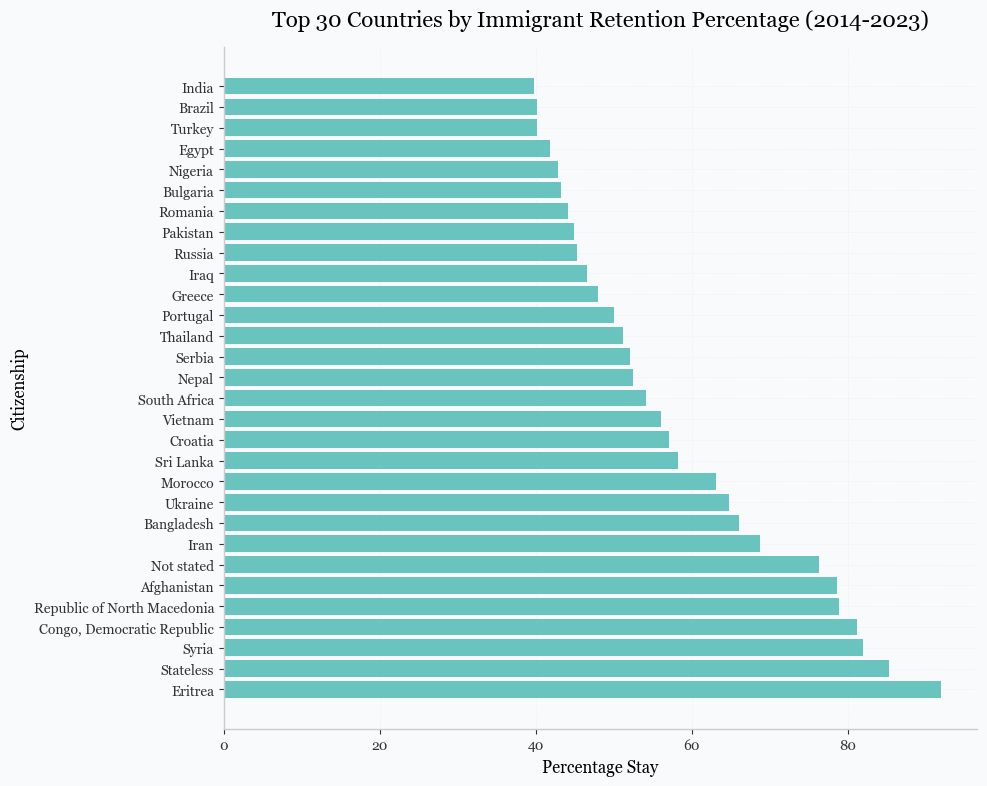

In [6]:
# First, apply the custom styling
cvs.setup_styling()

# Sorting to get the top 30 values
top_30 = merged_df.sort_values(by="Percentage stay").tail(30)

# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the horizontal bar chart using the custom teal color
ax.barh(top_30["Citizenship"], top_30["Percentage stay"], color=cvs.TEAL)

# Apply the custom styling to the chart
cvs.apply_chart_style(
    ax,
    title="Top 30 Countries by Immigrant Retention Percentage (2014-2023)",
    xlabel="Percentage Stay",
    ylabel="Citizenship",
    grid=True
)

# Invert y-axis for better readability
ax.invert_yaxis()

# Show the plot
plt.tight_layout()
plt.show()

# If you want to save the figure with the custom background
cvs.savefig_with_background(fig, "immigration_stay_top_30_2023.png")

Custom visualization styling applied successfully.


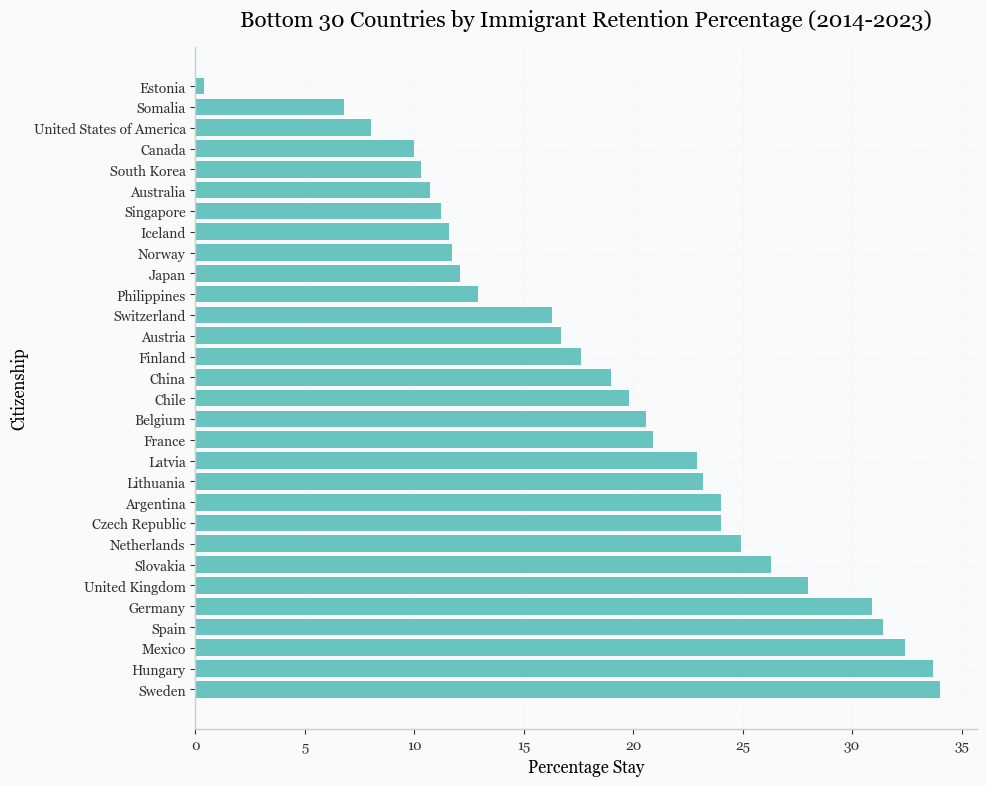

In [7]:
# First, apply the custom styling
cvs.setup_styling()

# Sorting to get the bottom 30 values
bottom_30 = merged_df.sort_values(by="Percentage stay").head(30)

# Create the figure and axes
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the horizontal bar chart using the custom teal color
ax.barh(bottom_30["Citizenship"], bottom_30["Percentage stay"], color=cvs.TEAL)

# Apply the custom styling to the chart
cvs.apply_chart_style(
    ax,
    title="Bottom 30 Countries by Immigrant Retention Percentage (2014-2023)",
    xlabel="Percentage Stay",
    ylabel="Citizenship",
    grid=True
)

# Invert y-axis for better readability
ax.invert_yaxis()

# Show the plot
plt.tight_layout()
plt.show()

# If you want to save the figure with the custom background
cvs.savefig_with_background(fig, "immigration_stay_bottom_30_2023.png")

In [8]:
# Initialize a folium map
m = folium.Map(location=[20, 0], zoom_start=2)

# Add a new property to each feature in the geojson for 'Percentage stay' value
for feature in geojson_data['features']:
    country_name = feature['properties']['name']
    # Find the matching 'Percentage stay' value for each country
    stay_value = merged_df.loc[merged_df['Citizenship'] == country_name, 'Percentage stay']
    # If there's a match, add it as a string to the GeoJSON feature; otherwise, set as 'N/A'
    feature['properties']['Percentage stay'] = (
        str(stay_value.values[0]) if not stay_value.empty else 'N/A'
    )

# Add GeoJSON data to the map with color coding and tooltips
folium.Choropleth(
    geo_data=geojson_data,
    name='choropleth',
    data=merged_df,
    columns=['Citizenship', 'Percentage stay'],
    key_on='feature.properties.name',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Percentage Stay (%)',
    highlight=True,
    nan_fill_color='white'
).add_to(m)

# Add tooltips for each country including the 'Percentage stay' value
folium.GeoJson(
    geojson_data,
    style_function=lambda x: {'fillColor': 'transparent', 'color': 'black', 'weight': 0.5},
    tooltip=folium.GeoJsonTooltip(
        fields=['name', 'Percentage stay'],
        aliases=['Country:', 'Percentage Stay:']
    )
).add_to(m)

# Save the map to an HTML file
m.save('percentage_stay_map_2023.html')

# Display the map
m
